In [1]:
import healpy as hp
import numpy as np
import matplotlib.pyplot as plt
from src import satellite_properties as sat
from src import store_FOV_indices as fov

In [77]:
altitudes=[400]
_,rad=sat.calc_central_angle(altitudes)


The Radius of the Field of View for a height of 400.00 km in radians is 0.35


In [78]:
lon=np.linspace(-180,180,3072)
lat=np.linspace(0,0,3072)
pix_array=(hp.ang2pix(16,lon,lat,lonlat=True))
disc_pix=fov.get_disc(16,lon,lat,rad,pix_array)

In [79]:
np.shape(disc_pix)

(3072, 1)

In [80]:
def shapecheck(lon,lat):
    checkpix=hp.ang2pix(128,lon,lat,lonlat=True)
    checkmap=np.zeros(hp.nside2npix(128))
    for pi in checkpix:
        checkmap[pi]+=1
    checkmap=np.where(checkmap != 0, 1, 0)
    return hp.mollview(checkmap,flip='geo')
    


In [88]:
lon1,lat1=hp.pix2ang(16,disc_pix[200][0],lonlat=True)

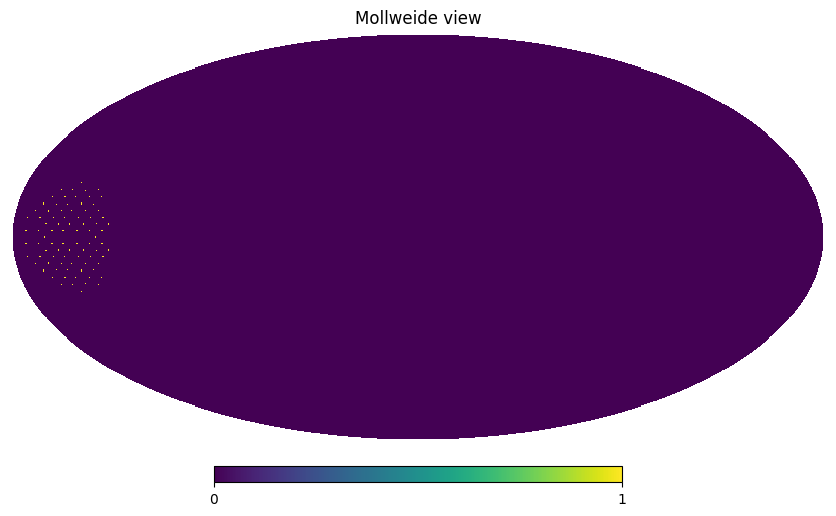

In [89]:
shapecheck(lon1,lat1)

In [28]:
disc_pix[0][0]

array([1023, 1024, 1087, 1088, 1089, 1150, 1151, 1152, 1153, 1214, 1215,
       1216, 1217, 1218, 1277, 1278, 1279, 1280, 1281, 1282, 1341, 1342,
       1343, 1344, 1345, 1346, 1347, 1405, 1406, 1407, 1408, 1409, 1410,
       1469, 1470, 1471, 1472, 1473, 1474, 1475, 1532, 1533, 1534, 1535,
       1536, 1537, 1538, 1539, 1597, 1598, 1599, 1600, 1601, 1602, 1603,
       1661, 1662, 1663, 1664, 1665, 1666, 1725, 1726, 1727, 1728, 1729,
       1730, 1731, 1789, 1790, 1791, 1792, 1793, 1794, 1854, 1855, 1856,
       1857, 1858, 1918, 1919, 1920, 1921, 1983, 1984, 1985, 2047, 2048])

In [18]:
import numpy as np

# Function to transform coordinates
def transform_coordinates(coords, inclination):
    # Convert inclination to radians
    inclination_rad = np.radians(inclination)
    
    # Rotation matrix around x-axis (line of nodes)
    rotation_matrix = np.array([[1, 0, 0],
                                 [0, np.cos(inclination_rad), -np.sin(inclination_rad)],
                                 [0, np.sin(inclination_rad), np.cos(inclination_rad)]])
    
    # Convert coordinates to Cartesian
    x = coords[0]
    y = coords[1]
    z = coords[2]
    
    # Apply rotation
    transformed_coords = np.dot(rotation_matrix, np.array([x, y, z]))
    return transformed_coords
    
time_res=10000
x=np.linspace(-180,180,time_res)
y=np.zeros(len(x))
z=np.full((x.shape),6800)
# Example coordinates
geodetic_coords = (x, y, z)  # Replace x, y, z with your actual coordinates
inclination = 30  # Example inclination angle in degrees

# Transform coordinates
new_coords = transform_coordinates(geodetic_coords, inclination)

print("Transformed coordinates:", new_coords)


Transformed coordinates: [[ -180.          -179.9639964   -179.9279928  ...   179.9279928
    179.9639964    180.        ]
 [-3400.         -3400.         -3400.         ... -3400.
  -3400.         -3400.        ]
 [ 5888.97274573  5888.97274573  5888.97274573 ...  5888.97274573
   5888.97274573  5888.97274573]]


In [35]:
from pyproj import Proj, transform

# Define projection for geodetic coordinates (WGS84)
wgs84 = Proj(proj='latlong', datum='WGS84')

# Define projection for Cartesian coordinates (assuming WGS84 ellipsoid)
cartesian_proj = Proj(proj='geocent', datum='WGS84')

# Function to convert Cartesian coordinates to geodetic
def cartesian_to_geodetic(coords):
    lon, lat, alt = transform(cartesian_proj, wgs84, coords[0], coords[1], coords[2], radians=False)
    return lon, lat, alt

# Example transformed coordinates
transformed_coords = (new_coords[0], new_coords[1],new_coords[2])  # Replace x, y, z with your actual transformed coordinates

# Convert transformed coordinates to geodetic
geodetic_coords = cartesian_to_geodetic(transformed_coords)

print("Transformed coordinates in geodetic form:", geodetic_coords)


Transformed coordinates in geodetic form: (array([-93.03047685, -93.02987182, -93.02926679, ..., -86.97073321,
       -86.97012818, -86.96952315]), array([90., 90., 90., ..., 90., 90., 90.]), array([-6350863.34149945, -6350863.34149945, -6350863.34149945, ...,
       -6350863.34149945, -6350863.34149945, -6350863.34149945]))


/tmp/ipykernel_173415/3358244760.py:11: FutureWarning: This function is deprecated. See: https://pyproj4.github.io/pyproj/stable/gotchas.html#upgrading-to-pyproj-2-from-pyproj-1
  lon, lat, alt = transform(cartesian_proj, wgs84, coords[0], coords[1], coords[2], radians=False)
